In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

import candel
from candel import SPEED_OF_LIGHT
from h5py import File

from utils import *

from scipy.stats import norm
from astropy.cosmology import FlatLambdaCDM
import seaborn as sns

%matplotlib inline
%load_ext autoreload
%autoreload 2

root = "/Users/rstiskalek/Projects/CANDEL/results/CCHP"

config_path = "/Users/rstiskalek/Projects/CANDEL/scripts/runs/configs/config_shoes.toml"
data = candel.pvdata.load_SH0ES_from_config(config_path)

import candel

COLS = ["#87193d", "#1e42b9", "#d42a29", "#05dd6b", "#ee35d5"]


2025-12-16 11:25:05 warning: zero width found in the priors. Setting it to 1e-5.
2025-12-16 11:25:05 indices of zero width: [44]
2025-12-16 11:25:05 found zero-width prior at index 44. Setting it to 0.
2025-12-16 11:25:05 Masking Cepheids with cz_cmb > 5000 km/s: Keeping 37 out of 37.


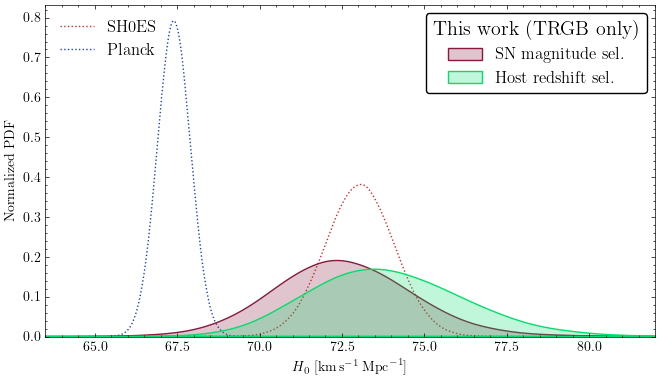

In [3]:
fnames = [
    "CCHP_beta_1.0_sel-SN_magnitude_manticore_2MPP_MULTIBIN_N256_DES_V2.hdf5",
    "CCHP_beta_1.0_sel-redshift_manticore_2MPP_MULTIBIN_N256_DES_V2.hdf5",
    "CCHP_beta_1.0_manticore_2MPP_MULTIBIN_N256_DES_V2.hdf5",
]


labels = [
    "SN magnitude sel.",
    "Host redshift sel.",
    "No selection",
]


H0s = [read_samples(root, f, "H0") for f in fnames]


fig_width = 6.8  # inches
fig_height = 4.0
bw = 2.0
cols = COLS


with plt.style.context("science"):
    plt.figure(figsize=(fig_width, fig_height))

    # Main posteriors
    cols_here = ["#87193d", "#05dd6b"]
    for H0, lab, col in zip(H0s, labels, cols_here):
        if lab == "No selection":
            sns.kdeplot(
                H0,
                label=lab,
                fill=False,
                ls="dashed",
                color="black",
                bw_adjust=bw,
            )
        else:
            sns.kdeplot(
                H0,
                label=lab,
                fill=True,
                bw_adjust=bw,
                color=col,
            )

    # Reference constraints
    sns.kdeplot(
        norm(73.04, 1.04).rvs(size=500_000),
        label="SH0ES",
        fill=False,
        ls="dotted",
        color=cols[2],
        bw_adjust=bw,
        zorder=-1,
    )

    sns.kdeplot(
        norm(67.4, 0.5).rvs(size=500_000),
        label="Planck",
        fill=False,
        ls="dotted",
        color=cols[1],
        bw_adjust=bw,
        zorder=-1,
    )

    plt.xlabel(r"$H_0~[\mathrm{km}\,\mathrm{s}^{-1}\,\mathrm{Mpc}^{-1}]$")
    plt.ylabel("Normalized PDF")

    ax = plt.gca()

    # Split legends
    handles, labels_all = ax.get_legend_handles_labels()

    main_h, main_l = [], []
    ref_h, ref_l = [], []

    for h, l in zip(handles, labels_all):
        if l in ["SH0ES", "Planck"]:
            ref_h.append(h)
            ref_l.append(l)
        else:
            main_h.append(h)
            main_l.append(l)

    legend1 = ax.legend(
        main_h,
        main_l,
        loc="upper right",
        fontsize="large",
        title="This work (TRGB only)",
        title_fontsize="x-large",
        frameon=True,
        edgecolor="black",
        facecolor="white",
        fancybox=True,
        framealpha=1,
    )
    ax.add_artist(legend1)

    ax.legend(
        ref_h,
        ref_l,
        loc="upper left",
        fontsize="large",
    )

    plt.xlim(63.5, 82)
    plt.tight_layout()
    plt.savefig(
        "/Users/rstiskalek/Downloads/H0_comparison_CCHP.pdf",
        dpi=500,
        bbox_inches="tight",
    )
    plt.show()

